# CISI Future Projections
Runs the trained CNN on SSP scenario inputs for 2030, 2050, and 2100.
Fill in the file paths marked `# TODO` before running.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
from pathlib import Path
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [2]:
class CNN(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(config['dropout']), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(config['dropout']), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(config['dropout']), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.Dropout(config['dropout']),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)

## Paths fill in before running

In [3]:
# Model
MODEL_PATH = 'best_search_model.pt'

# Reference raster â€” used to align all inputs to same grid
REFERENCE_RASTER = r'READY_data\labels\2024_CISI_010deg_nearest.tif'

# Shapefile for map borders
SHP_PATH = r'ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp'

# Output folder
OUTPUT_DIR = 'predictions'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Normalized SSP input directory (output of preprocess_ssp_inputs.ipynb)
NORM_DIR = r'READY_data\inputs_normalized\ssp'

SCENARIOS = {
    'SSP1': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP1_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP1_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP1_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP2': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP2_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP2_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP2_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP3': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP3_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP3_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP3_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP4': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP4_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP4_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP4_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
    'SSP5': {
        2030: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2030_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2030_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2030_class_{c}.tif' for c in range(1, 8)],
        },
        2050: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2050_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2050_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2050_class_{c}.tif' for c in range(1, 8)],
        },
        2100: {
            'gdp': rf'{NORM_DIR}\GDP_SSP5_2100_normalized.tif',
            'pop': rf'{NORM_DIR}\POP_SSP5_2100_normalized.tif',
            'lc':  [rf'{NORM_DIR}\LC_SSP5_2100_class_{c}.tif' for c in range(1, 8)],
        },
    },
}

## Load model

In [4]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
config = checkpoint.get('params', checkpoint.get('config', {'dropout': 0.2}))
model = CNN({'dropout': config['dropout']}).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Model loaded from {MODEL_PATH}')
print(f'Config: {config}')

Model loaded from best_search_model.pt
Config: {'lam': 30, 'lr': 0.00021583385016821986, 'dropout': 0.2}


## Helper: load and align raster to reference grid

In [5]:
def load_aligned(path, ref_shape, ref_transform, ref_crs):
    """Read a raster — must already match the reference grid (no resampling)."""
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
    if (data.shape[1], data.shape[2]) != ref_shape:
        raise ValueError(f'Shape mismatch in {os.path.basename(path)}: {data.shape[1:]} != {ref_shape}')
    return data  # shape: (bands, H, W)


def build_input_stack(gdp_path, pop_path, lc_paths, ref_shape, ref_transform, ref_crs):
    """Stack GDP + POP + 7 LC classes into (9, H, W) array, NaN → 0."""
    gdp = load_aligned(gdp_path, ref_shape, ref_transform, ref_crs)[0]
    pop = load_aligned(pop_path, ref_shape, ref_transform, ref_crs)[0]
    lc  = np.concatenate([load_aligned(p, ref_shape, ref_transform, ref_crs) for p in lc_paths], axis=0)
    stack = np.stack([gdp, pop, *lc], axis=0)  # (9, H, W)
    stack = np.nan_to_num(stack, nan=0.0)
    return stack


# Load reference grid info
with rasterio.open(REFERENCE_RASTER) as ref:
    REF_SHAPE     = (ref.height, ref.width)
    REF_TRANSFORM = ref.transform
    REF_CRS       = ref.crs
    REF_PROFILE   = ref.profile.copy()
    VALID_MASK    = ~np.isnan(ref.read(1))

print(f'Reference grid: {REF_SHAPE}, CRS: {REF_CRS}')
print(f'Valid pixels: {VALID_MASK.sum():,}')

Reference grid: (485, 570), CRS: EPSG:4326
Valid pixels: 87,346


## Pre-flight alignment check

Verifies that every input file for every scenario has the correct shape, CRS, and transform before any inference runs. Stops early if anything is misaligned.

In [6]:
issues = []

for ssp, years in SCENARIOS.items():
    for year, paths in years.items():
        all_paths = [paths['gdp'], paths['pop']] + paths['lc']
        for p in all_paths:
            if not os.path.exists(p):
                issues.append(f'MISSING   {ssp} {year}: {os.path.basename(p)}')
                continue
            with rasterio.open(p) as src:
                shape = (src.height, src.width)
                crs   = src.crs
                transform = src.transform
            if shape != REF_SHAPE:
                issues.append(f'SHAPE     {ssp} {year}: {os.path.basename(p)} — {shape} != {REF_SHAPE}')
            if crs != REF_CRS:
                issues.append(f'CRS       {ssp} {year}: {os.path.basename(p)} — {crs} != {REF_CRS}')
            if not all(abs(transform[i] - REF_TRANSFORM[i]) < 1e-6 for i in range(6)):
                issues.append(f'TRANSFORM {ssp} {year}: {os.path.basename(p)} — transform mismatch')

if issues:
    print(f'FOUND {len(issues)} ISSUE(S) — fix before running projections:\n')
    for iss in issues:
        print(f'  {iss}')
    raise RuntimeError('Input alignment check failed. See issues above.')
else:
    print(f'All inputs verified — {sum(len(y) * 9 for y in SCENARIOS.values())} files checked. Ready to run.')

All inputs verified — 135 files checked. Ready to run.


In [8]:
PATCH_SIZE = 16
HALF       = PATCH_SIZE // 2

def predict_raster(input_stack):
    """Run model on every valid pixel and return prediction raster (H, W)."""
    H, W = REF_SHAPE
    pred_map = np.full((H, W), np.nan, dtype=np.float32)
    valid_idx = np.argwhere(VALID_MASK)

    patches, coords = [], []
    for i, j in valid_idx:
        pad_top    = max(0, HALF - i)
        pad_bottom = max(0, (i + HALF) - H)
        pad_left   = max(0, HALF - j)
        pad_right  = max(0, (j + HALF) - W)
        i0 = max(0, i - HALF); i1 = min(H, i + HALF)
        j0 = max(0, j - HALF); j1 = min(W, j + HALF)
        patch = input_stack[:, i0:i1, j0:j1].copy()
        if pad_top or pad_bottom or pad_left or pad_right:
            patch = np.pad(patch, ((0,0),(pad_top,pad_bottom),(pad_left,pad_right)), mode='edge')
        patches.append(patch)
        coords.append((i, j))

        if len(patches) == 512:
            batch = torch.FloatTensor(np.stack(patches)).to(device)
            with torch.no_grad():
                preds = model(batch).cpu().numpy().flatten()
            for (pi, pj), p in zip(coords, preds):
                pred_map[pi, pj] = p
            patches, coords = [], []

    if patches:
        batch = torch.FloatTensor(np.stack(patches)).to(device)
        with torch.no_grad():
            preds = model(batch).cpu().numpy().flatten()
        for (pi, pj), p in zip(coords, preds):
            pred_map[pi, pj] = p

    return pred_map


results = {}

for ssp, years in SCENARIOS.items():
    results[ssp] = {}
    for year, paths in years.items():
        # Skip if any normalized input file is missing
        missing = [p for p in [paths['gdp'], paths['pop']] + paths['lc'] if not os.path.exists(p)]
        if missing:
            print(f'SKIPPING {ssp} {year} â€” missing files:')
            for m in missing:
                print(f'  {m}')
            continue

        print(f'Running {ssp} {year}...')
        stack = build_input_stack(
            paths['gdp'], paths['pop'], paths['lc'],
            REF_SHAPE, REF_TRANSFORM, REF_CRS
        )
        pred = predict_raster(stack)
        results[ssp][year] = pred

        out_path = f'{OUTPUT_DIR}/cisi_pred_{ssp}_{year}.tif'
        profile = REF_PROFILE.copy()
        profile.update(dtype='float32', count=1, nodata=np.nan)
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(pred[np.newaxis, :, :])
        print(f'  Saved {out_path}  |  mean={np.nanmean(pred):.4f}  max={np.nanmax(pred):.4f}')

print('\nDone.')

Running SSP1 2030...
  Saved predictions/cisi_pred_SSP1_2030.tif  |  mean=0.0406  max=0.2120
Running SSP1 2050...
  Saved predictions/cisi_pred_SSP1_2050.tif  |  mean=0.0408  max=0.2141
Running SSP1 2100...
  Saved predictions/cisi_pred_SSP1_2100.tif  |  mean=0.0408  max=0.2037
Running SSP2 2030...
  Saved predictions/cisi_pred_SSP2_2030.tif  |  mean=0.0403  max=0.2113
Running SSP2 2050...
  Saved predictions/cisi_pred_SSP2_2050.tif  |  mean=0.0405  max=0.2131
Running SSP2 2100...
  Saved predictions/cisi_pred_SSP2_2100.tif  |  mean=0.0408  max=0.1974
Running SSP3 2030...
  Saved predictions/cisi_pred_SSP3_2030.tif  |  mean=0.0403  max=0.2132
Running SSP3 2050...
  Saved predictions/cisi_pred_SSP3_2050.tif  |  mean=0.0405  max=0.2130
Running SSP3 2100...
  Saved predictions/cisi_pred_SSP3_2100.tif  |  mean=0.0407  max=0.1879
Running SSP4 2030...
  Saved predictions/cisi_pred_SSP4_2030.tif  |  mean=0.0404  max=0.2186
Running SSP4 2050...
  Saved predictions/cisi_pred_SSP4_2050.tif  |  m

## Maps one figure per year, all SSPs

Saved projections_2030.png


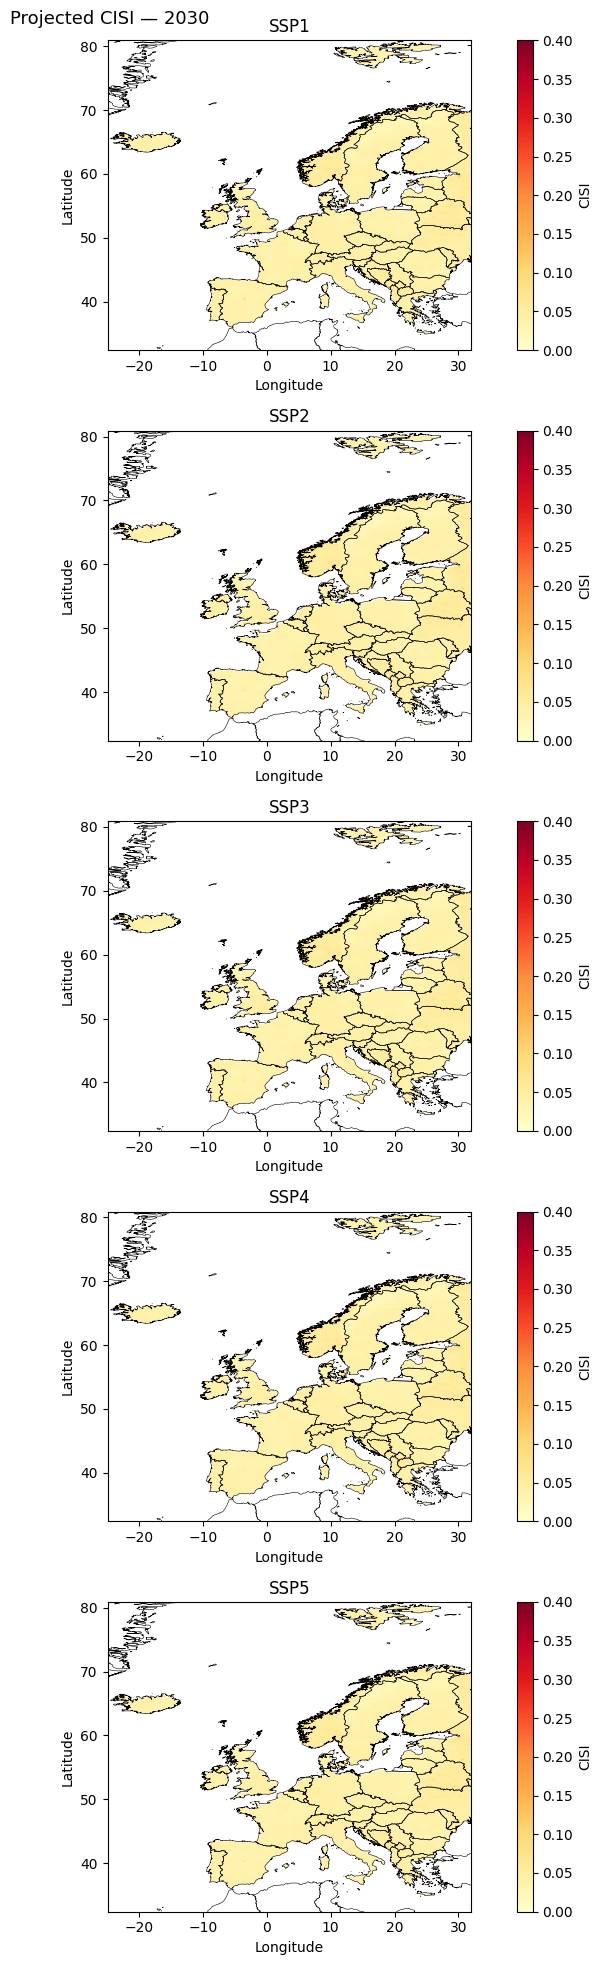

Saved projections_2050.png


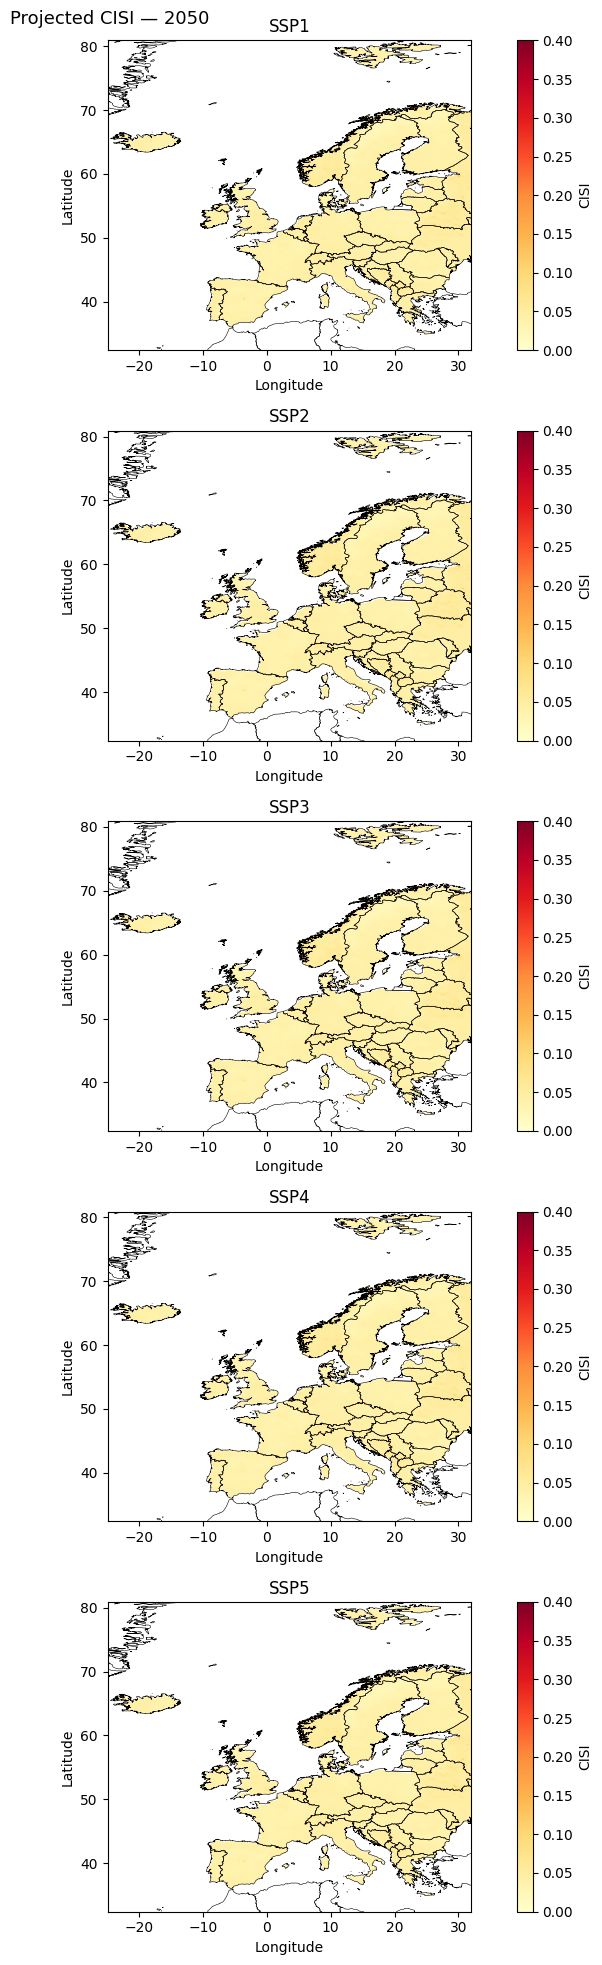

Saved projections_2100.png


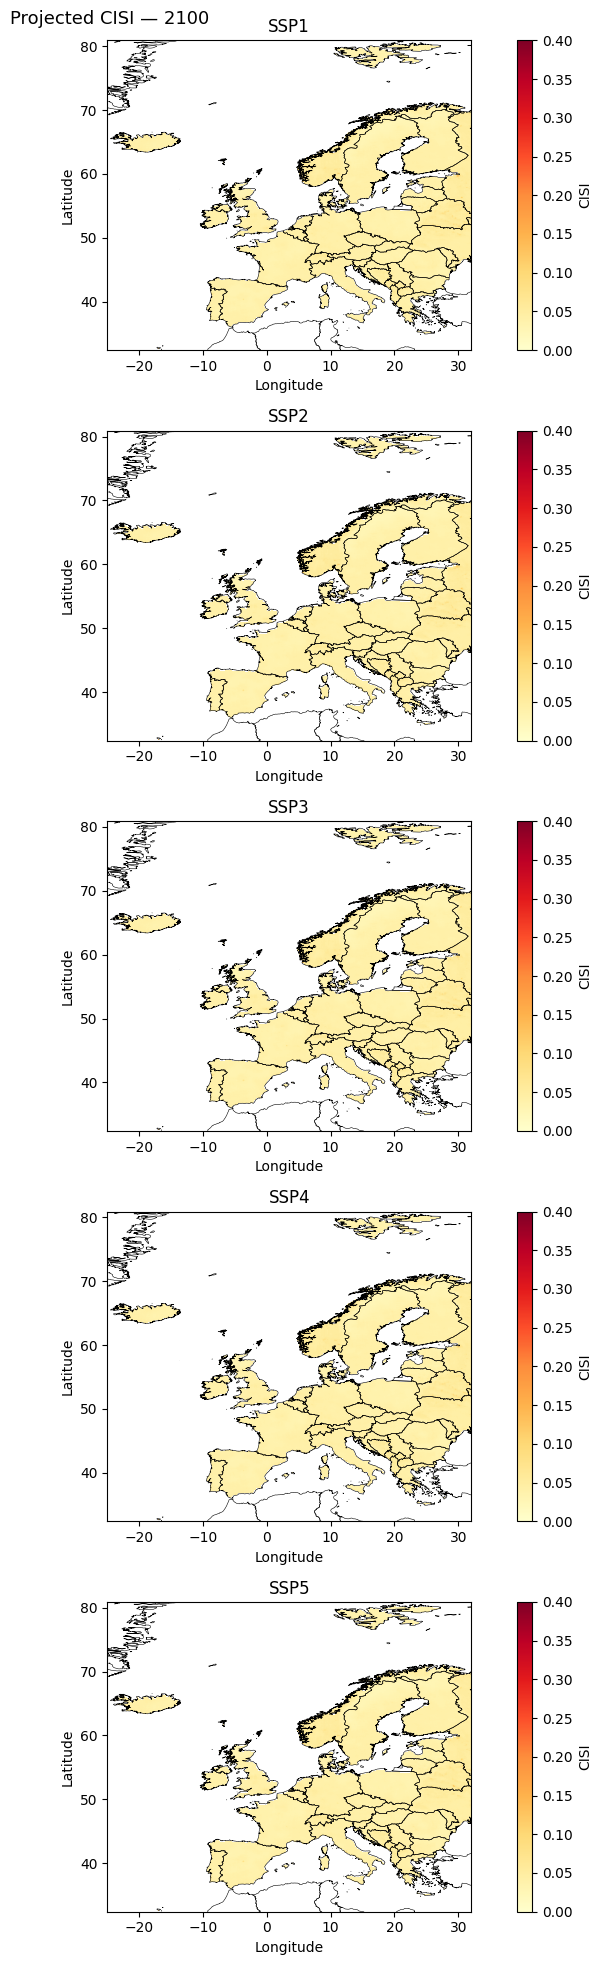

In [11]:
world = gpd.read_file(SHP_PATH)

SSPS  = [s for s in SCENARIOS if results.get(s)]
YEARS = [2030, 2050, 2100]

for year in YEARS:
    ssps_with_data = [s for s in SSPS if year in results[s]]
    if not ssps_with_data:
        continue

    fig, axes = plt.subplots(len(ssps_with_data), 1,
                             figsize=(10, 4 * len(ssps_with_data)))
    if len(ssps_with_data) == 1:
        axes = [axes]
    fig.suptitle(f"Projected CISI — {year}", fontsize=13)

    with rasterio.open(REFERENCE_RASTER) as ref:
        bounds = ref.bounds

    for ax, ssp in zip(axes, ssps_with_data):
        pred = results[ssp][year]
        im = ax.imshow(pred, cmap="YlOrRd", vmin=0, vmax=0.4,
                       extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
                       origin="upper", aspect="auto")
        world.boundary.plot(ax=ax, linewidth=0.4, color="black")
        ax.set_xlim(bounds.left, bounds.right)
        ax.set_ylim(bounds.bottom, bounds.top)
        plt.colorbar(im, ax=ax, label="CISI", fraction=0.03)
        ax.set_title(ssp)
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    plt.tight_layout()
    out_fig = f"projections_{year}.png"
    plt.savefig(out_fig, dpi=150, bbox_inches="tight")
    print(f"Saved {out_fig}")
    plt.show()


## Summary statistics per SSP and year

In [20]:
print(f"{'SSP':<6} {'Year':>6} {'Mean':>8} {'Std':>8} {'Max':>8} {'High>0.15 (%)':>14}")
print('-' * 50)
for ssp in SSPS:
    for year in YEARS:
        if year not in results.get(ssp, {}):
            continue
        pred  = results[ssp][year]
        valid = pred[~np.isnan(pred)]
        high  = (valid > 0.15).mean() * 100
        print(f"{ssp:<6} {year:>6} {valid.mean():>8.4f} {valid.std():>8.4f} {valid.max():>8.4f} {high:>13.1f}%")

SSP      Year     Mean      Std      Max  High>0.15 (%)
--------------------------------------------------
SSP1     2030   0.0406   0.0078   0.2120           0.0%
SSP1     2050   0.0408   0.0077   0.2141           0.0%
SSP1     2100   0.0408   0.0077   0.2037           0.0%
SSP2     2030   0.0403   0.0078   0.2113           0.0%
SSP2     2050   0.0405   0.0077   0.2131           0.0%
SSP2     2100   0.0408   0.0077   0.1974           0.0%
SSP3     2030   0.0403   0.0078   0.2132           0.0%
SSP3     2050   0.0405   0.0076   0.2130           0.0%
SSP3     2100   0.0407   0.0074   0.1879           0.0%
SSP4     2030   0.0404   0.0077   0.2186           0.0%
SSP4     2050   0.0406   0.0076   0.2182           0.0%
SSP4     2100   0.0407   0.0076   0.1999           0.0%
SSP5     2030   0.0404   0.0078   0.2209           0.0%
SSP5     2050   0.0406   0.0077   0.2253           0.0%
SSP5     2100   0.0407   0.0076   0.1983           0.0%


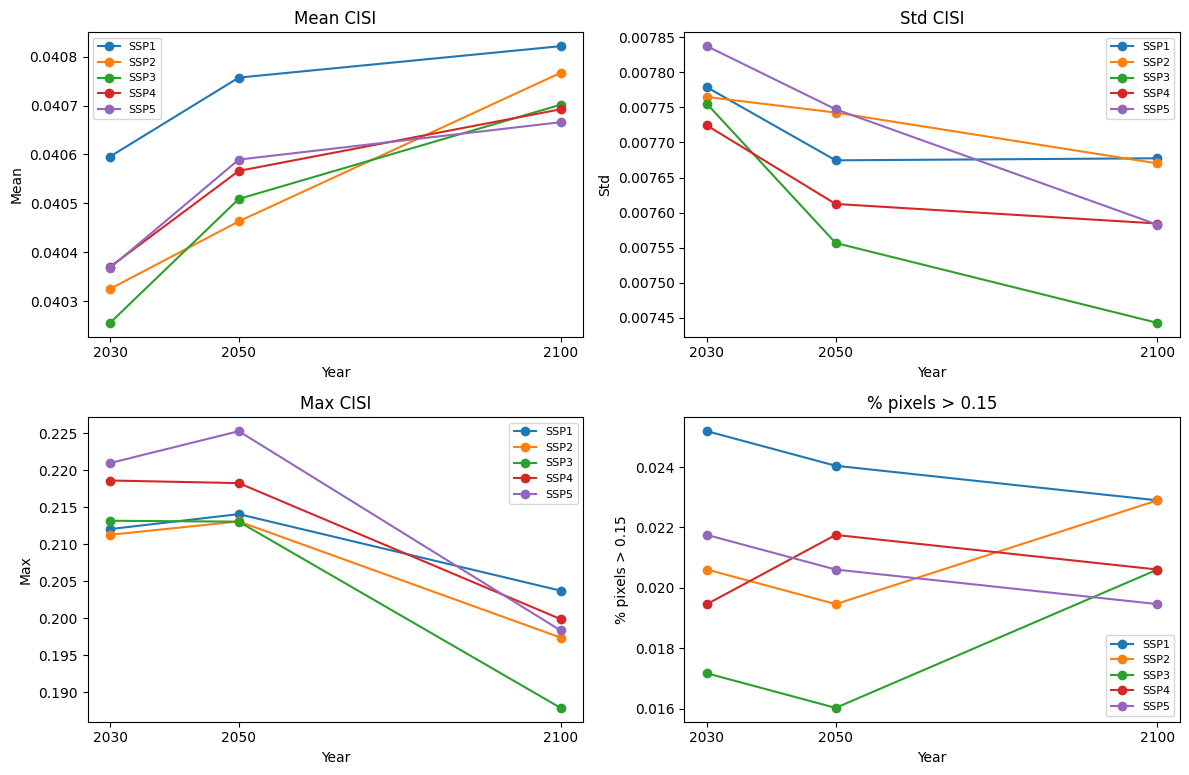

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("", fontsize=13)

stats = {ssp: {metric: [] for metric in ["mean", "std", "max", "high"]} for ssp in SSPS}
for ssp in SSPS:
    for year in YEARS:
        if year not in results.get(ssp, {}):
            for m in stats[ssp]: stats[ssp][m].append(np.nan)
            continue
        valid = results[ssp][year][~np.isnan(results[ssp][year])]
        stats[ssp]["mean"].append(valid.mean())
        stats[ssp]["std"].append(valid.std())
        stats[ssp]["max"].append(valid.max())
        stats[ssp]["high"].append((valid > 0.15).mean() * 100)

titles  = ["Mean CISI", "Std CISI", "Max CISI", "% pixels > 0.15"]
keys    = ["mean", "std", "max", "high"]
ylabels = ["Mean", "Std", "Max", "% pixels > 0.15"]

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        ax.plot(YEARS, stats[ssp][key], marker="o", label=ssp)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(YEARS)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("summary_stats.png", dpi=150, bbox_inches="tight")
plt.show()

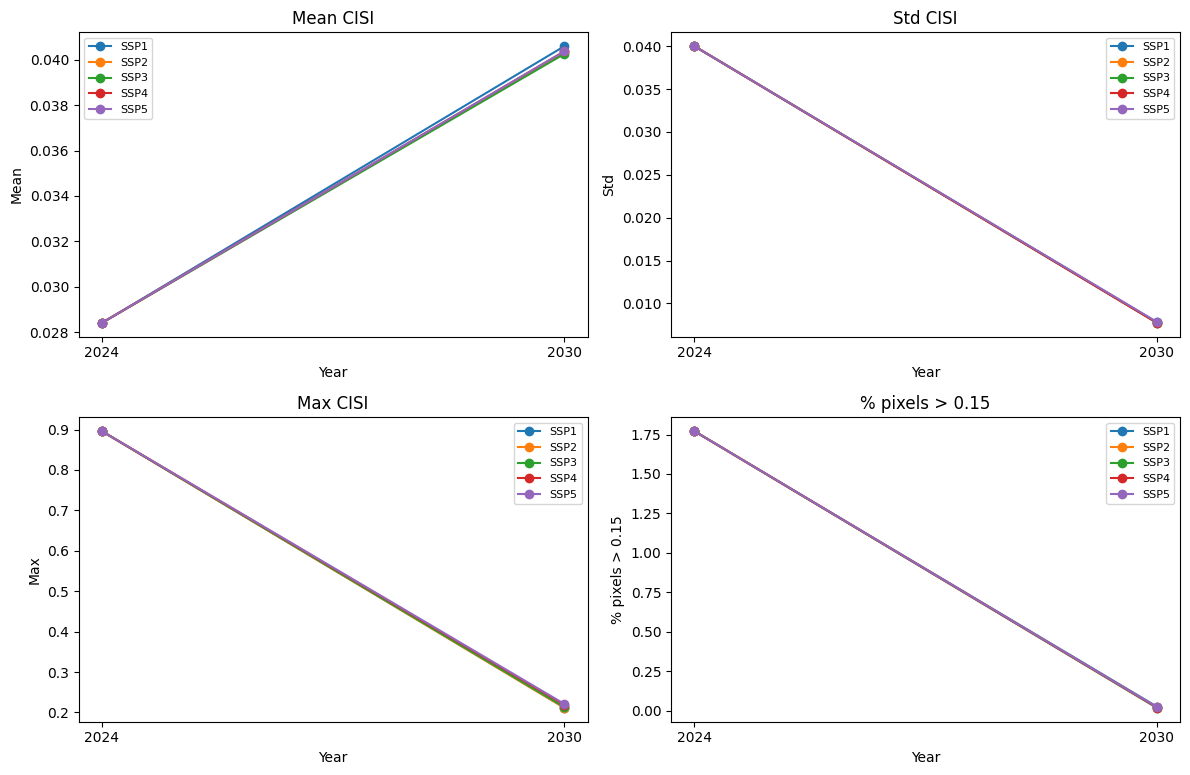

In [25]:
# Load 2024 observed CISI
with rasterio.open(REFERENCE_RASTER) as src:
    cisi_2024 = src.read(1).astype(np.float32)

valid_2024 = cisi_2024[~np.isnan(cisi_2024)]
stats_2024 = {
    "mean": valid_2024.mean(),
    "std":  valid_2024.std(),
    "max":  valid_2024.max(),
    "high": (valid_2024 > 0.15).mean() * 100,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("", fontsize=13)

keys    = ["mean", "std", "max", "high"]
titles  = ["Mean CISI", "Std CISI", "Max CISI", "% pixels > 0.15"]
ylabels = ["Mean", "Std", "Max", "% pixels > 0.15"]

for ax, key, title, ylabel in zip(axes.flat, keys, titles, ylabels):
    for ssp in SSPS:
        y_2024 = stats_2024[key]
        y_2030 = stats[ssp][key][YEARS.index(2030)]
        ax.plot([2024, 2030], [y_2024, y_2030], marker="o", label=ssp)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks([2024, 2030])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("stats_2024_2030.png", dpi=150, bbox_inches="tight")
plt.show()